# Irrigation Decision and Optimization

The forecasting experiments provide an estimate of how soil moisture may change over the next hour, together with an indication of prediction uncertainty. The next question is how this information can support an irrigation decision.

In this notebook, I use the digital twin forecasts to investigate when irrigation may be needed and how different decision strategies affect water use and soil-moisture conditions.

I compare three approaches:

- a simple fixed irrigation strategy
- a soil-moisture threshold strategy
- a forecast-based strategy that also considers prediction uncertainty

The available dataset does not provide enough field information to convert the recorded irrigation variable into a reliable water depth for the entire field. I therefore treat irrigation as an effective control action rather than presenting the results as field-ready irrigation quantities.

The aim is to test the decision framework and understand whether forecast information can reduce unnecessary irrigation while maintaining acceptable soil-moisture conditions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    "../data/processed/irrigation_model_data.csv"
)

data["Timestamps"] = pd.to_datetime(
    data["Timestamps"]
)

data = data.sort_values("Timestamps").reset_index(drop=True)

data = data.drop_duplicates(
    subset="Timestamps",
    keep="first"
).reset_index(drop=True)

soil_ports = [
    "Port1", "Port2", "Port3",
    "Port4", "Port5", "Port6"
]

train_end = pd.Timestamp(
    "2022-10-23 11:30:00"
)

train_data = data[
    data["Timestamps"] <= train_end
].copy()

print("Training observations:", len(train_data))

print(
    "Training period:",
    train_data["Timestamps"].min(),
    "to",
    train_data["Timestamps"].max()
)

print("\nSoil-moisture distribution:\n")

print(
    train_data[soil_ports]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90
        ]
    )
    .T[
        [
            "mean",
            "std",
            "min",
            "10%",
            "25%",
            "50%",
            "75%",
            "90%",
            "max"
        ]
    ]
)

Training observations: 8014
Training period: 2022-08-01 00:15:00 to 2022-10-23 11:30:00

Soil-moisture distribution:

           mean       std    min    10%    25%    50%    75%     90%    max
Port1  0.215068  0.039085  0.159  0.167  0.180  0.208  0.249  0.2710  0.339
Port2  0.139973  0.025683  0.119  0.124  0.127  0.131  0.136  0.1960  0.244
Port3  0.196632  0.044780  0.145  0.151  0.157  0.180  0.237  0.2660  0.320
Port4  0.196369  0.030641  0.154  0.156  0.166  0.195  0.223  0.2360  0.321
Port5  0.210115  0.041096  0.171  0.174  0.175  0.189  0.247  0.2747  0.366
Port6  0.183305  0.036990  0.140  0.149  0.152  0.169  0.206  0.2430  0.350


## Decision threshold

The six soil sensors have different moisture distributions, so I did not apply one raw threshold across all of them. The forecasting model predicts the one-hour change in Port1, so I used Port1 as the state variable for the irrigation decision.

I selected the 25th percentile of Port1 in the training data as an experimental lower operating threshold. This gives a value of 0.180.

This threshold is not intended to represent a crop-specific wilting point or a field recommendation. It provides a data-based reference for comparing irrigation strategies without selecting the threshold from the test data.

In [3]:
import joblib
import torch
import torch.nn as nn

feature_scaler = joblib.load(
    "../models/physics_feature_scaler.pkl"
)

target_scaler = joblib.load(
    "../models/physics_target_scaler.pkl"
)

checkpoint = torch.load(
    "../models/physics_guided_lstm.pth",
    map_location="cpu",
    weights_only=False
)

physics_features = checkpoint["physics_features"]
sequence_length = checkpoint["sequence_length"]

print("Model features:", len(physics_features))
print("Sequence length:", sequence_length)
print("Forecast horizon:", checkpoint["forecast_horizon_minutes"], "minutes")
print("\nFeatures:")
print(physics_features)

Model features: 13
Sequence length: 12
Forecast horizon: 60 minutes

Features:
['Port1', 'Port2', 'Port3', 'Port4', 'Port5', 'Port6', 'Rainfall', 'Irrigation_filled', 'Irrigation_missing', 'Temperature', 'Rainfall_prev_1h', 'Irrigation_prev_1h', 'water_input_prev_1h']


In [8]:
# Reconstruct the forecasting data

model_data = data.copy()

# Preserve whether irrigation was originally missing
model_data["Irrigation_missing"] = (
    model_data["Irrigation"]
    .isna()
    .astype(int)
)

# Numerical input used by the forecasting model
model_data["Irrigation_filled"] = (
    model_data["Irrigation"]
    .fillna(0)
)

# Create the exact one-hour forecasting target
model_data["target_time"] = (
    model_data["Timestamps"]
    + pd.Timedelta(hours=1)
)

future_port1 = (
    model_data[
        ["Timestamps", "Port1"]
    ]
    .rename(
        columns={
            "Timestamps": "target_time",
            "Port1": "future_Port1"
        }
    )
)

model_data = model_data.merge(
    future_port1,
    on="target_time",
    how="left"
)

model_data["delta_theta_1h"] = (
    model_data["future_Port1"]
    - model_data["Port1"]
)

# Identify continuous 15-minute sections
time_difference = (
    model_data["Timestamps"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

new_group = (
    time_difference.ne(15)
)

model_data["continuous_group"] = (
    new_group.cumsum()
)

# Previous-hour rainfall
model_data["Rainfall_prev_1h"] = (
    model_data
    .groupby("continuous_group")["Rainfall"]
    .transform(
        lambda x: x.shift(1)
        .rolling(
            window=4,
            min_periods=4
        )
        .sum()
    )
)

# Previous-hour irrigation
model_data["Irrigation_prev_1h"] = (
    model_data
    .groupby("continuous_group")["Irrigation_filled"]
    .transform(
        lambda x: x.shift(1)
        .rolling(
            window=4,
            min_periods=4
        )
        .sum()
    )
)

# Empirical combined water-input indicator
model_data["water_input_prev_1h"] = (
    model_data["Rainfall_prev_1h"]
    + model_data["Irrigation_prev_1h"]
)

# Keep observations with an exact one-hour target
physics_data = (
    model_data[
        model_data["delta_theta_1h"].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

# Use the same chronological split as the forecasting model
n_total = len(physics_data)

train_end_index = int(n_total * 0.70)
val_end_index = int(n_total * 0.80)

train_phys = (
    physics_data
    .iloc[:train_end_index]
    .copy()
)

val_phys = (
    physics_data
    .iloc[train_end_index:val_end_index]
    .copy()
)

test_phys = (
    physics_data
    .iloc[val_end_index:]
    .copy()
)

print(
    "Target-valid observations:",
    len(physics_data)
)

print(
    "Training:",
    len(train_phys)
)

print(
    "Validation:",
    len(val_phys)
)

print(
    "Test:",
    len(test_phys)
)

print(
    "\nTest period:",
    test_phys["Timestamps"].min(),
    "to",
    test_phys["Timestamps"].max()
)

Target-valid observations: 11449
Training: 8014
Validation: 1145
Test: 2290

Test period: 2022-11-04 10:00:00 to 2023-02-28 22:45:00


In [9]:
# Build continuous forecasting sequences

def build_sequences(frame, features, target, sequence_length=12):

    X = []
    y = []
    times = []

    frame = frame.reset_index(drop=True)

    for i in range(sequence_length - 1, len(frame)):

        window = frame.iloc[
            i - sequence_length + 1:i + 1
        ]

        time_gaps = (
            window["Timestamps"]
            .diff()
            .dropna()
            .dt.total_seconds()
            .div(60)
        )

        if not (time_gaps == 15).all():
            continue

        if window[features].isna().any().any():
            continue

        target_value = frame.iloc[i][target]

        if pd.isna(target_value):
            continue

        X.append(
            window[features].to_numpy(dtype=float)
        )

        y.append(target_value)

        times.append(
            frame.iloc[i]["Timestamps"]
        )

    return (
        np.asarray(X),
        np.asarray(y),
        np.asarray(times)
    )


X_train_phys_raw, y_train_phys_raw, train_phys_times = (
    build_sequences(
        train_phys,
        physics_features,
        "delta_theta_1h",
        sequence_length
    )
)

X_val_phys_raw, y_val_phys_raw, val_phys_times = (
    build_sequences(
        val_phys,
        physics_features,
        "delta_theta_1h",
        sequence_length
    )
)

X_test_phys_raw, clean_targets, test_phys_times = (
    build_sequences(
        test_phys,
        physics_features,
        "delta_theta_1h",
        sequence_length
    )
)

print("Training sequences:", X_train_phys_raw.shape)
print("Validation sequences:", X_val_phys_raw.shape)
print("Test sequences:", X_test_phys_raw.shape)

print("\nTest targets:", clean_targets.shape)
print("Test timestamps:", test_phys_times.shape)

Training sequences: (7999, 12, 13)
Validation sequences: (1134, 12, 13)
Test sequences: (1948, 12, 13)

Test targets: (1948,)
Test timestamps: (1948,)


In [11]:
# Load the saved physics-guided LSTM

class PhysicsInformedLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=32
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        _, (hidden, _) = self.lstm(x)

        return self.fc(
            hidden[-1]
        )


model = PhysicsInformedLSTM(
    input_size=len(physics_features),
    hidden_size=checkpoint["hidden_size"]
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()


# Scale each sequence with the saved training scaler

def scale_sequences(X, scaler):

    original_shape = X.shape

    X_2d = X.reshape(
        -1,
        original_shape[-1]
    )

    X_scaled = scaler.transform(
        X_2d
    )

    return X_scaled.reshape(
        original_shape
    )


X_val_scaled = scale_sequences(
    X_val_phys_raw,
    feature_scaler
)

X_test_scaled = scale_sequences(
    X_test_phys_raw,
    feature_scaler
)


# Generate one-hour soil-moisture-change forecasts

def predict_delta(model, X_scaled, target_scaler):

    X_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    )

    with torch.no_grad():

        predictions_scaled = (
            model(X_tensor)
            .cpu()
            .numpy()
        )

    predictions = (
        target_scaler
        .inverse_transform(
            predictions_scaled
        )
        .reshape(-1)
    )

    return predictions


val_predictions = predict_delta(
    model,
    X_val_scaled,
    target_scaler
)

clean_predictions = predict_delta(
    model,
    X_test_scaled,
    target_scaler
)


# Convert validation targets to one-dimensional form

val_targets = (
    y_val_phys_raw
    .reshape(-1)
)


# clean_targets already came from the Day 6 sequence-building cell

clean_targets = np.asarray(
    clean_targets
).reshape(-1)


print(
    "Validation predictions:",
    val_predictions.shape
)

print(
    "Validation targets:",
    val_targets.shape
)

print(
    "Test predictions:",
    clean_predictions.shape
)

print(
    "Test targets:",
    clean_targets.shape
)

print(
    "\nPrediction range:",
    clean_predictions.min(),
    "to",
    clean_predictions.max()
)

print(
    "Observed range:",
    clean_targets.min(),
    "to",
    clean_targets.max()
)

Validation predictions: (1134,)
Validation targets: (1134,)
Test predictions: (1948,)
Test targets: (1948,)

Prediction range: -0.000915353 to 0.0005793862
Observed range: -0.0020000000000000018 to 0.010999999999999982


In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Verify forecasting performance on the untouched test period

test_mae = mean_absolute_error(
    clean_targets,
    clean_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        clean_targets,
        clean_predictions
    )
)

test_r2 = r2_score(
    clean_targets,
    clean_predictions
)


# Calibrate uncertainty using validation residuals only

validation_residuals = np.abs(
    val_targets - val_predictions
)

alpha = 0.10

n_cal = len(validation_residuals)

quantile_level = (
    np.ceil((n_cal + 1) * (1 - alpha))
    / n_cal
)

quantile_level = min(
    quantile_level,
    1.0
)

q_hat = np.quantile(
    validation_residuals,
    quantile_level,
    method="higher"
)


# Construct the 90% test prediction interval

lower_delta = (
    clean_predictions - q_hat
)

upper_delta = (
    clean_predictions + q_hat
)

coverage = np.mean(
    (clean_targets >= lower_delta)
    &
    (clean_targets <= upper_delta)
)

outside_interval = np.sum(
    (clean_targets < lower_delta)
    |
    (clean_targets > upper_delta)
)


print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

print(
    "\nConformal quantile level:",
    quantile_level
)

print(
    "90% uncertainty margin:",
    q_hat
)

print(
    "Observed test coverage:",
    coverage
)

print(
    "Forecasts outside interval:",
    outside_interval
)

Test MAE: 0.0003999095575549949
Test RMSE: 0.0008168562114091785
Test R²: -0.14397902229517268

Conformal quantile level: 0.9012345679012346
90% uncertainty margin: 0.0008818308522459128
Observed test coverage: 0.9383983572895277
Forecasts outside interval: 120


In [13]:
# Convert predicted moisture change into future Port1 moisture

port1_index = physics_features.index("Port1")

current_port1 = (
    X_test_phys_raw[:, -1, port1_index]
)

predicted_future_port1 = (
    current_port1
    + clean_predictions
)

observed_future_port1 = (
    current_port1
    + clean_targets
)

lower_future_port1 = (
    current_port1
    + lower_delta
)

upper_future_port1 = (
    current_port1
    + upper_delta
)

theta_low = 0.180


print(
    "Current Port1 range:",
    current_port1.min(),
    "to",
    current_port1.max()
)

print(
    "Predicted future Port1 range:",
    predicted_future_port1.min(),
    "to",
    predicted_future_port1.max()
)

print(
    "Observed future Port1 range:",
    observed_future_port1.min(),
    "to",
    observed_future_port1.max()
)

print(
    "\nExperimental lower threshold:",
    theta_low
)

print(
    "Current observations below threshold:",
    np.sum(current_port1 < theta_low)
)

print(
    "Predicted future observations below threshold:",
    np.sum(predicted_future_port1 < theta_low)
)

print(
    "Lower uncertainty bounds below threshold:",
    np.sum(lower_future_port1 < theta_low)
)

print(
    "Observed future observations below threshold:",
    np.sum(observed_future_port1 < theta_low)
)


Current Port1 range: 0.222 to 0.302
Predicted future Port1 range: 0.2218863831133349 to 0.3014120543124154
Observed future Port1 range: 0.222 to 0.302

Experimental lower threshold: 0.18
Current observations below threshold: 0
Predicted future observations below threshold: 0
Lower uncertainty bounds below threshold: 0
Observed future observations below threshold: 0


     Split  Minimum  25th percentile  Median  75th percentile  Maximum
  Training    0.159            0.180   0.208            0.249    0.339
Validation    0.223            0.228   0.235            0.243    0.248
      Test    0.222            0.246   0.251            0.257    0.305


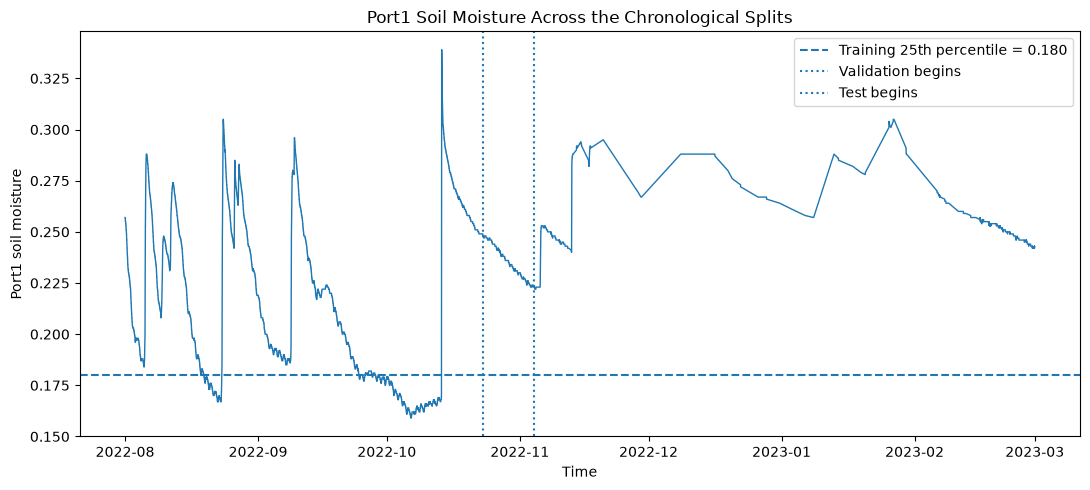

In [14]:
# Examine how Port1 moisture changes across the chronological data splits

split_summary = pd.DataFrame({
    "Split": [
        "Training",
        "Validation",
        "Test"
    ],
    "Minimum": [
        train_phys["Port1"].min(),
        val_phys["Port1"].min(),
        test_phys["Port1"].min()
    ],
    "25th percentile": [
        train_phys["Port1"].quantile(0.25),
        val_phys["Port1"].quantile(0.25),
        test_phys["Port1"].quantile(0.25)
    ],
    "Median": [
        train_phys["Port1"].median(),
        val_phys["Port1"].median(),
        test_phys["Port1"].median()
    ],
    "75th percentile": [
        train_phys["Port1"].quantile(0.75),
        val_phys["Port1"].quantile(0.75),
        test_phys["Port1"].quantile(0.75)
    ],
    "Maximum": [
        train_phys["Port1"].max(),
        val_phys["Port1"].max(),
        test_phys["Port1"].max()
    ]
})

print(split_summary.to_string(index=False))


plt.figure(figsize=(11, 5))

plt.plot(
    physics_data["Timestamps"],
    physics_data["Port1"],
    linewidth=1
)

plt.axhline(
    0.180,
    linestyle="--",
    label="Training 25th percentile = 0.180"
)

plt.axvline(
    val_phys["Timestamps"].iloc[0],
    linestyle=":",
    label="Validation begins"
)

plt.axvline(
    test_phys["Timestamps"].iloc[0],
    linestyle=":",
    label="Test begins"
)

plt.xlabel("Time")
plt.ylabel("Port1 soil moisture")
plt.title("Port1 Soil Moisture Across the Chronological Splits")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Examine recorded irrigation behaviour in the training period

training_irrigation = train_phys[
    [
        "Timestamps",
        "Port1",
        "Irrigation",
        "Irrigation_filled",
        "Irrigation_missing"
    ]
].copy()

positive_irrigation = training_irrigation[
    training_irrigation["Irrigation"].notna()
    &
    (training_irrigation["Irrigation"] > 0)
].copy()

known_irrigation = training_irrigation[
    training_irrigation["Irrigation"].notna()
].copy()

print(
    "Training observations:",
    len(training_irrigation)
)

print(
    "Known irrigation observations:",
    len(known_irrigation)
)

print(
    "Missing irrigation observations:",
    training_irrigation["Irrigation_missing"].sum()
)

print(
    "Positive irrigation observations:",
    len(positive_irrigation)
)

if len(positive_irrigation) > 0:

    print(
        "\nPositive irrigation values:"
    )

    print(
        positive_irrigation["Irrigation"]
        .describe()
    )

    print(
        "\nPort1 when positive irrigation was recorded:"
    )

    print(
        positive_irrigation["Port1"]
        .describe(
            percentiles=[
                0.10,
                0.25,
                0.50,
                0.75,
                0.90
            ]
        )
    )

    print(
        "\nFirst recorded positive irrigation observations:"
    )

    print(
        positive_irrigation[
            [
                "Timestamps",
                "Port1",
                "Irrigation"
            ]
        ]
        .head(15)
        .to_string(index=False)
    )

Training observations: 8014
Known irrigation observations: 8014
Missing irrigation observations: 0
Positive irrigation observations: 818

Positive irrigation values:
count    818.000000
mean       0.820440
std        0.681459
min        0.010000
25%        0.220000
50%        0.650000
75%        1.427500
max        7.660000
Name: Irrigation, dtype: float64

Port1 when positive irrigation was recorded:
count    818.000000
mean       0.211560
std        0.038022
min        0.161000
10%        0.169000
25%        0.184000
50%        0.198000
75%        0.236000
90%        0.276300
max        0.334000
Name: Port1, dtype: float64

First recorded positive irrigation observations:
         Timestamps  Port1  Irrigation
2022-08-03 07:30:00  0.198        0.21
2022-08-03 07:45:00  0.198        0.03
2022-08-03 08:15:00  0.197        0.70
2022-08-03 08:30:00  0.197        0.74
2022-08-03 08:45:00  0.197        0.77
2022-08-03 09:00:00  0.197        0.76
2022-08-03 09:15:00  0.196        0.68
2022-

In [16]:
# Examine irrigation frequency across training soil-moisture ranges

moisture_bins = [
    -np.inf,
    0.18,
    0.20,
    0.22,
    0.24,
    0.26,
    np.inf
]

moisture_labels = [
    "< 0.18",
    "0.18 - 0.20",
    "0.20 - 0.22",
    "0.22 - 0.24",
    "0.24 - 0.26",
    ">= 0.26"
]

training_irrigation["Moisture_range"] = pd.cut(
    training_irrigation["Port1"],
    bins=moisture_bins,
    labels=moisture_labels,
    right=False
)

training_irrigation["Positive_irrigation"] = (
    training_irrigation["Irrigation"].fillna(0) > 0
).astype(int)

irrigation_by_moisture = (
    training_irrigation
    .groupby(
        "Moisture_range",
        observed=False
    )
    .agg(
        Observations=("Port1", "size"),
        Irrigation_observations=(
            "Positive_irrigation",
            "sum"
        ),
        Mean_irrigation=(
            "Irrigation_filled",
            "mean"
        )
    )
)

irrigation_by_moisture[
    "Irrigation_frequency"
] = (
    irrigation_by_moisture[
        "Irrigation_observations"
    ]
    /
    irrigation_by_moisture[
        "Observations"
    ]
)

print(irrigation_by_moisture)

                Observations  Irrigation_observations  Mean_irrigation  \
Moisture_range                                                           
< 0.18                  1945                      140         0.034021   
0.18 - 0.20             1655                      271         0.129094   
0.20 - 0.22              913                      101         0.104337   
0.22 - 0.24              960                      139         0.151229   
0.24 - 0.26             1134                       60         0.056199   
>= 0.26                 1407                      107         0.061926   

                Irrigation_frequency  
Moisture_range                        
< 0.18                      0.071979  
0.18 - 0.20                 0.163746  
0.20 - 0.22                 0.110624  
0.22 - 0.24                 0.144792  
0.24 - 0.26                 0.052910  
>= 0.26                     0.076048  


In [17]:
# Define a normalized Port1 operating state from training data

theta_dry = train_phys["Port1"].quantile(0.10)
theta_wet = train_phys["Port1"].quantile(0.90)

def normalize_moisture(theta):

    normalized = (
        (theta - theta_dry)
        /
        (theta_wet - theta_dry)
    )

    return np.clip(
        normalized,
        0,
        1
    )


current_state = normalize_moisture(
    current_port1
)

predicted_future_state = normalize_moisture(
    predicted_future_port1
)

lower_future_state = normalize_moisture(
    lower_future_port1
)

observed_future_state = normalize_moisture(
    observed_future_port1
)


print(
    "Training dry reference:",
    theta_dry
)

print(
    "Training wet reference:",
    theta_wet
)

print(
    "\nCurrent normalized state:",
    current_state.min(),
    "to",
    current_state.max()
)

print(
    "Predicted future state:",
    predicted_future_state.min(),
    "to",
    predicted_future_state.max()
)

print(
    "Lower uncertainty state:",
    lower_future_state.min(),
    "to",
    lower_future_state.max()
)

print(
    "Observed future state:",
    observed_future_state.min(),
    "to",
    observed_future_state.max()
)

Training dry reference: 0.167
Training wet reference: 0.271

Current normalized state: 0.5288461538461537 to 1.0
Predicted future state: 0.5277536837820661 to 1.0
Lower uncertainty state: 0.5192745409720092 to 1.0
Observed future state: 0.5288461538461537 to 1.0


## Irrigation decision policies

The historical irrigation records do not show a simple relationship between Port1 moisture and irrigation activity. I therefore did not try to infer a field irrigation threshold directly from those records.

For this decision experiment, I represent Port1 moisture relative to the 10th and 90th percentiles observed in the training period. I use a normalized value of 0.60 as an experimental lower operating target. This corresponds to a Port1 value of approximately 0.2294 based on the training distribution.

The value is used to compare decision strategies rather than as a crop-specific irrigation recommendation.

Three decision rules are considered. A fixed strategy provides a simple time-based reference. A state-based strategy responds when the current normalized moisture is below the operating target. The forecast-based strategy acts when the lower bound of the one-hour forecast falls below the target, allowing forecast uncertainty to influence the decision.

In [18]:
# Define the experimental operating target

operating_target = 0.60

theta_operating_target = (
    theta_dry
    + operating_target
    * (theta_wet - theta_dry)
)

# Current-state decision
state_based_action = (
    current_state < operating_target
).astype(int)

# Forecast-only decision
forecast_action = (
    predicted_future_state < operating_target
).astype(int)

# Uncertainty-aware forecast decision
uncertainty_action = (
    lower_future_state < operating_target
).astype(int)

# Actual future low-moisture condition
observed_low_state = (
    observed_future_state < operating_target
).astype(int)


print(
    "Normalized operating target:",
    operating_target
)

print(
    "Equivalent Port1 target:",
    theta_operating_target
)

print(
    "\nState-based irrigation decisions:",
    state_based_action.sum()
)

print(
    "Forecast-based irrigation decisions:",
    forecast_action.sum()
)

print(
    "Uncertainty-aware irrigation decisions:",
    uncertainty_action.sum()
)

print(
    "Observed future low-moisture cases:",
    observed_low_state.sum()
)

Normalized operating target: 0.6
Equivalent Port1 target: 0.22940000000000002

State-based irrigation decisions: 119
Forecast-based irrigation decisions: 119
Uncertainty-aware irrigation decisions: 120
Observed future low-moisture cases: 115


In [19]:
# Evaluate each decision rule against future low-moisture conditions

def evaluate_policy(actions, observed_low):

    actions = np.asarray(actions)
    observed_low = np.asarray(observed_low)

    true_positive = np.sum(
        (actions == 1) & (observed_low == 1)
    )

    false_positive = np.sum(
        (actions == 1) & (observed_low == 0)
    )

    false_negative = np.sum(
        (actions == 0) & (observed_low == 1)
    )

    true_negative = np.sum(
        (actions == 0) & (observed_low == 0)
    )

    precision = (
        true_positive /
        (true_positive + false_positive)
        if (true_positive + false_positive) > 0
        else np.nan
    )

    recall = (
        true_positive /
        (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else np.nan
    )

    return {
        "Actions": int(actions.sum()),
        "Detected low-moisture cases": int(true_positive),
        "Unnecessary actions": int(false_positive),
        "Missed low-moisture cases": int(false_negative),
        "Correct no-action cases": int(true_negative),
        "Precision": precision,
        "Recall": recall
    }


state_results = evaluate_policy(
    state_based_action,
    observed_low_state
)

forecast_results = evaluate_policy(
    forecast_action,
    observed_low_state
)

uncertainty_results = evaluate_policy(
    uncertainty_action,
    observed_low_state
)


policy_results = pd.DataFrame(
    [
        state_results,
        forecast_results,
        uncertainty_results
    ],
    index=[
        "Current-state",
        "Forecast-based",
        "Uncertainty-aware"
    ]
)

print(policy_results)

                   Actions  Detected low-moisture cases  Unnecessary actions  \
Current-state          119                          115                    4   
Forecast-based         119                          115                    4   
Uncertainty-aware      120                          115                    5   

                   Missed low-moisture cases  Correct no-action cases  \
Current-state                              0                     1829   
Forecast-based                             0                     1829   
Uncertainty-aware                          0                     1828   

                   Precision  Recall  
Current-state       0.966387     1.0  
Forecast-based      0.966387     1.0  
Uncertainty-aware   0.958333     1.0  


In [20]:
# Construct a fixed-schedule reference from training irrigation frequency

training_irrigation_frequency = (
    positive_irrigation.shape[0]
    /
    training_irrigation.shape[0]
)

observations_per_action = int(
    round(
        1 / training_irrigation_frequency
    )
)

fixed_interval_minutes = (
    observations_per_action * 15
)

print(
    "Training irrigation frequency:",
    training_irrigation_frequency
)

print(
    "Approximate observations per action:",
    observations_per_action
)

print(
    "Fixed schedule interval:",
    fixed_interval_minutes,
    "minutes"
)


# Apply the regular schedule to the test decision timestamps

test_times = pd.to_datetime(
    test_phys_times
)

fixed_action = np.zeros(
    len(test_times),
    dtype=int
)

schedule_start = test_times[0]

next_irrigation_time = schedule_start

for i, timestamp in enumerate(test_times):

    if timestamp >= next_irrigation_time:

        fixed_action[i] = 1

        next_irrigation_time = (
            timestamp
            + pd.Timedelta(
                minutes=fixed_interval_minutes
            )
        )


fixed_results = evaluate_policy(
    fixed_action,
    observed_low_state
)

print(
    "\nFixed-schedule irrigation decisions:",
    fixed_action.sum()
)

print(
    "Detected low-moisture cases:",
    fixed_results[
        "Detected low-moisture cases"
    ]
)

print(
    "Unnecessary actions:",
    fixed_results[
        "Unnecessary actions"
    ]
)

print(
    "Missed low-moisture cases:",
    fixed_results[
        "Missed low-moisture cases"
    ]
)

print(
    "Precision:",
    fixed_results["Precision"]
)

print(
    "Recall:",
    fixed_results["Recall"]
)

Training irrigation frequency: 0.10207137509358623
Approximate observations per action: 10
Fixed schedule interval: 150 minutes

Fixed-schedule irrigation decisions: 200
Detected low-moisture cases: 12
Unnecessary actions: 188
Missed low-moisture cases: 103
Precision: 0.06
Recall: 0.10434782608695652


In [21]:
# Compare the irrigation decision strategies

all_policy_results = pd.DataFrame(
    [
        fixed_results,
        state_results,
        forecast_results,
        uncertainty_results
    ],
    index=[
        "Fixed schedule",
        "Current-state",
        "Forecast-based",
        "Uncertainty-aware"
    ]
)

# Use the fixed schedule as the reference for the action-use proxy

fixed_action_count = fixed_results["Actions"]

all_policy_results[
    "Action reduction vs fixed (%)"
] = (
    (
        fixed_action_count
        - all_policy_results["Actions"]
    )
    / fixed_action_count
    * 100
)

# Percentage of future low-moisture cases that were missed

total_low_cases = observed_low_state.sum()

all_policy_results[
    "Missed low-moisture cases (%)"
] = (
    all_policy_results[
        "Missed low-moisture cases"
    ]
    / total_low_cases
    * 100
)

print(
    all_policy_results.round(4)
)

                   Actions  Detected low-moisture cases  Unnecessary actions  \
Fixed schedule         200                           12                  188   
Current-state          119                          115                    4   
Forecast-based         119                          115                    4   
Uncertainty-aware      120                          115                    5   

                   Missed low-moisture cases  Correct no-action cases  \
Fixed schedule                           103                     1645   
Current-state                              0                     1829   
Forecast-based                             0                     1829   
Uncertainty-aware                          0                     1828   

                   Precision  Recall  Action reduction vs fixed (%)  \
Fixed schedule        0.0600  0.1043                            0.0   
Current-state         0.9664  1.0000                           40.5   
Forecast-based      

## Decision optimization

The rule-based comparisons show how different strategies respond to the same operating target. I also wanted to represent the irrigation decision as a small optimization problem.

For each decision time, the controller chooses between two actions: irrigate or do not irrigate. Irrigation carries a resource cost, while not irrigating carries a penalty when the forecast indicates that soil moisture may fall below the operating target.

I use the lower bound of the forecast interval to represent a conservative moisture estimate. The moisture deficit is normalized relative to the operating target, so the optimization remains dimensionless.

This formulation is a decision-support experiment. It does not estimate the physical amount of water required by the crop because the available data are not sufficient to convert an irrigation action into a reliable field-scale water depth.

In [22]:
# Optimize the binary irrigation decision

# Conservative forecast deficit
moisture_deficit = np.maximum(
    0,
    operating_target - lower_future_state
)

# Normalize deficit relative to the operating target
deficit_risk = (
    moisture_deficit
    / operating_target
)

# Decision costs
water_cost = 0.05
deficit_cost = 1.0

# Cost if irrigation is applied
cost_irrigate = np.full(
    len(deficit_risk),
    water_cost
)

# Cost if no irrigation is applied
cost_no_irrigation = (
    deficit_cost
    * deficit_risk
)

# Select the action with the lower cost
optimized_action = (
    cost_irrigate
    < cost_no_irrigation
).astype(int)

optimized_results = evaluate_policy(
    optimized_action,
    observed_low_state
)

print(
    "Optimized irrigation decisions:",
    optimized_action.sum()
)

print(
    "Detected low-moisture cases:",
    optimized_results[
        "Detected low-moisture cases"
    ]
)

print(
    "Unnecessary actions:",
    optimized_results[
        "Unnecessary actions"
    ]
)

print(
    "Missed low-moisture cases:",
    optimized_results[
        "Missed low-moisture cases"
    ]
)

print(
    "Precision:",
    optimized_results["Precision"]
)

print(
    "Recall:",
    optimized_results["Recall"]
)

print(
    "\nMaximum normalized deficit risk:",
    deficit_risk.max()
)

Optimized irrigation decisions: 119
Detected low-moisture cases: 115
Unnecessary actions: 4
Missed low-moisture cases: 0
Precision: 0.9663865546218487
Recall: 1.0

Maximum normalized deficit risk: 0.13454243171331798


## Resource-risk trade-off

The optimized decision depends on how strongly the controller values resource conservation relative to the risk of low soil moisture. A single cost value would therefore give only one view of the decision problem.

I tested several irrigation-action costs while keeping the moisture-deficit penalty fixed. These values are experimental weights rather than monetary or physical water costs. The purpose is to observe how the controller changes its decisions as irrigation becomes increasingly expensive in the objective function.

In [23]:
# Examine the trade-off between irrigation cost and moisture risk

water_cost_values = [
    0.00,
    0.01,
    0.025,
    0.05,
    0.075,
    0.10,
    0.125
]

optimization_results = []

for cost in water_cost_values:

    cost_irrigate = np.full(
        len(deficit_risk),
        cost
    )

    cost_no_irrigation = (
        deficit_cost
        * deficit_risk
    )

    actions = (
        cost_irrigate
        < cost_no_irrigation
    ).astype(int)

    results = evaluate_policy(
        actions,
        observed_low_state
    )

    optimization_results.append({
        "Water cost weight": cost,
        "Actions": results["Actions"],
        "Detected cases":
            results["Detected low-moisture cases"],
        "Unnecessary actions":
            results["Unnecessary actions"],
        "Missed cases":
            results["Missed low-moisture cases"],
        "Precision":
            results["Precision"],
        "Recall":
            results["Recall"]
    })


optimization_sensitivity = pd.DataFrame(
    optimization_results
)

optimization_sensitivity[
    "Action reduction vs fixed (%)"
] = (
    (
        fixed_action_count
        - optimization_sensitivity["Actions"]
    )
    / fixed_action_count
    * 100
)

print(
    optimization_sensitivity.round(4)
)

   Water cost weight  Actions  Detected cases  Unnecessary actions  \
0              0.000      120             115                    5   
1              0.010      119             115                    4   
2              0.025      119             115                    4   
3              0.050      119             115                    4   
4              0.075      118             115                    3   
5              0.100      117             115                    2   
6              0.125       21              21                    0   

   Missed cases  Precision  Recall  Action reduction vs fixed (%)  
0             0     0.9583  1.0000                           40.0  
1             0     0.9664  1.0000                           40.5  
2             0     0.9664  1.0000                           40.5  
3             0     0.9664  1.0000                           40.5  
4             0     0.9746  1.0000                           41.0  
5             0     0.9829  1.0

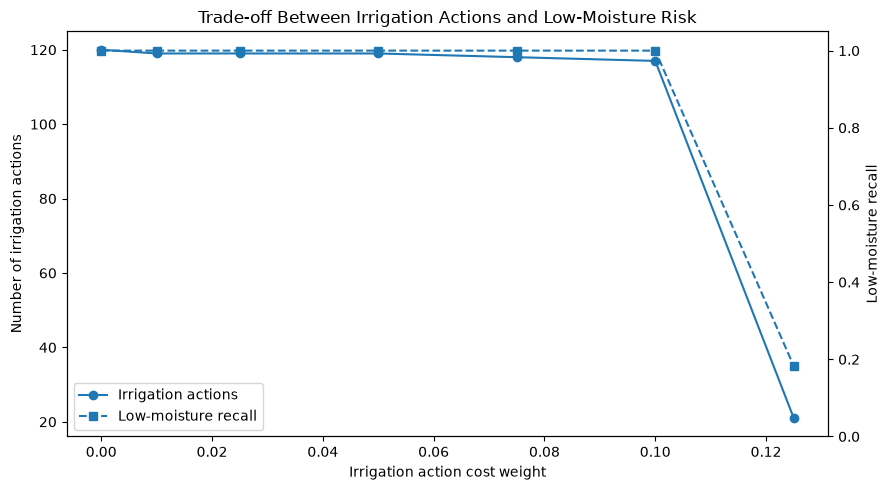

In [24]:
# Visualize the resource-risk trade-off

fig, ax1 = plt.subplots(
    figsize=(9, 5)
)

ax1.plot(
    optimization_sensitivity["Water cost weight"],
    optimization_sensitivity["Actions"],
    marker="o",
    label="Irrigation actions"
)

ax1.set_xlabel(
    "Irrigation action cost weight"
)

ax1.set_ylabel(
    "Number of irrigation actions"
)

ax2 = ax1.twinx()

ax2.plot(
    optimization_sensitivity["Water cost weight"],
    optimization_sensitivity["Recall"],
    marker="s",
    linestyle="--",
    label="Low-moisture recall"
)

ax2.set_ylabel(
    "Low-moisture recall"
)

ax2.set_ylim(
    0,
    1.05
)

lines_1, labels_1 = (
    ax1.get_legend_handles_labels()
)

lines_2, labels_2 = (
    ax2.get_legend_handles_labels()
)

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="lower left"
)

plt.title(
    "Trade-off Between Irrigation Actions and Low-Moisture Risk"
)

fig.tight_layout()

plt.show()

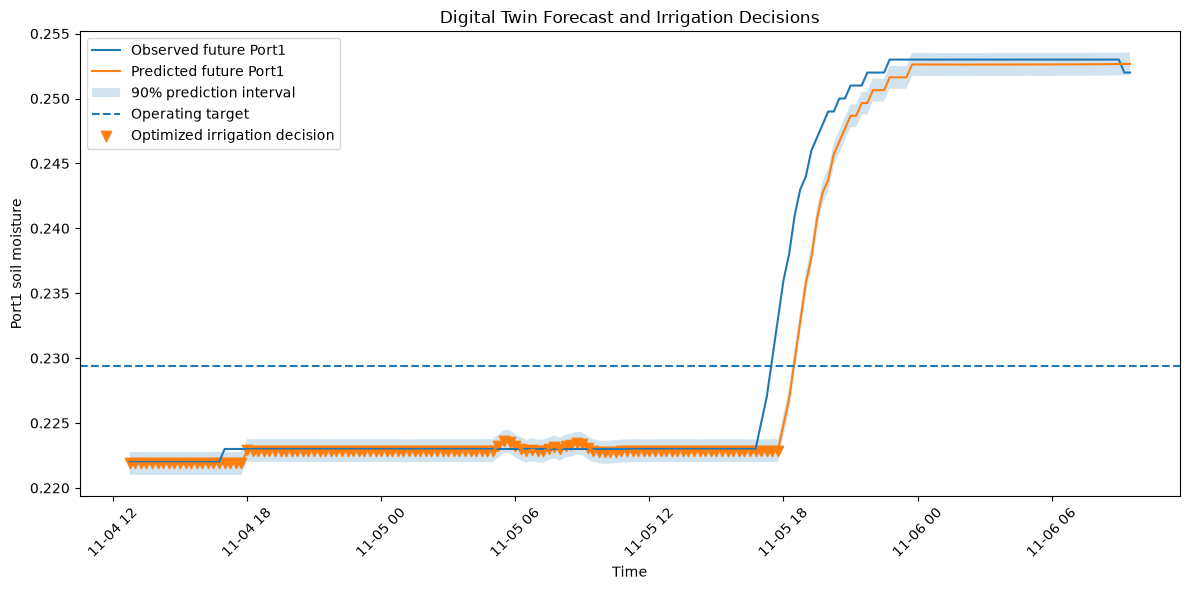

In [25]:
# Visualize the digital twin irrigation decisions over time

decision_cost = 0.10

decision_actions = (
    decision_cost < deficit_risk
).astype(int)

decision_frame = pd.DataFrame({
    "Timestamp": pd.to_datetime(test_phys_times),
    "Current_Port1": current_port1,
    "Predicted_future_Port1": predicted_future_port1,
    "Observed_future_Port1": observed_future_port1,
    "Lower_bound": lower_future_port1,
    "Upper_bound": upper_future_port1,
    "Irrigation_action": decision_actions
})

# Focus on a section where irrigation decisions occur
action_indices = np.where(
    decision_frame["Irrigation_action"].values == 1
)[0]

plot_start = max(
    0,
    action_indices[0] - 30
)

plot_end = min(
    len(decision_frame),
    plot_start + 180
)

plot_data = decision_frame.iloc[
    plot_start:plot_end
].copy()


plt.figure(
    figsize=(12, 6)
)

plt.plot(
    plot_data["Timestamp"],
    plot_data["Observed_future_Port1"],
    label="Observed future Port1",
    linewidth=1.5
)

plt.plot(
    plot_data["Timestamp"],
    plot_data["Predicted_future_Port1"],
    label="Predicted future Port1",
    linewidth=1.5
)

plt.fill_between(
    plot_data["Timestamp"],
    plot_data["Lower_bound"],
    plot_data["Upper_bound"],
    alpha=0.2,
    label="90% prediction interval"
)

plt.axhline(
    theta_operating_target,
    linestyle="--",
    label="Operating target"
)

action_data = plot_data[
    plot_data["Irrigation_action"] == 1
]

plt.scatter(
    action_data["Timestamp"],
    action_data["Predicted_future_Port1"],
    marker="v",
    s=55,
    label="Optimized irrigation decision"
)

plt.xlabel("Time")
plt.ylabel("Port1 soil moisture")

plt.title(
    "Digital Twin Forecast and Irrigation Decisions"
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

## What I learned from the irrigation decision experiment

The irrigation records in the training period did not show a simple relationship between Port1 moisture and irrigation activity. For that reason, I treated this part of the project as a decision-support experiment rather than attempting to reproduce the original field irrigation controller.

A fixed schedule derived from the training irrigation frequency produced 200 irrigation actions during the test decision period. Only 12 of those actions coincided with the 115 future low-moisture cases defined in this experiment, while 103 cases were missed.

The adaptive strategies behaved very differently. The current-state and one-hour forecast strategies each used 119 actions and detected all 115 low-moisture cases. The uncertainty-aware strategy used 120 actions and also detected all 115 cases. This corresponds to about a 40% reduction in decision actions relative to the fixed-schedule reference.

The forecast-based strategy did not outperform the current-state strategy at the selected operating target. Soil-moisture changes over the one-hour forecast horizon were generally small, so the current measurement and forecast often led to the same decision. This suggests that longer forecast horizons or additional environmental information may be needed before the forecasting model provides a stronger control advantage.

The optimization experiment exposed a clearer resource-risk trade-off. As the irrigation-action cost increased from 0 to 0.10, the number of actions decreased from 120 to 117 while all 115 defined low-moisture cases were still detected. At a cost weight of 0.125, however, the controller made only 21 decisions and missed 94 low-moisture cases. This shows how aggressively reducing irrigation actions can increase exposure to low-moisture risk.

The reported action reductions should not be interpreted as measured field water savings. The irrigation cost and action size are normalized, and the available data do not provide enough information to convert each decision into a reliable field-scale irrigation depth. The results therefore demonstrate the decision framework and its trade-offs rather than a field-ready irrigation prescription.